# Count the number of colocalization points in the Mediterranean sea
## What is done here ?
- select the drifters points under the swaths for each cycle considering drifters points for which it is the nearest swot image (one cycle every 23h50 approximately, e.g drifters in the $\pm$ 12h25 before and after the swot image)
- compute the minimum/maximum time gap for each swot image/cycle (will depend on the dt of the regular grid)

## Results ?
- some cycle are not available :
    - swath 3 : 498, 526-528, 566, 572
    - swath 16 : 480, 508, 513, 526-528, 534

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from rasterio.transform import Affine

import pynsitu as pyn

_______
# Select under swath drifters - create and store dataset

In [2]:
dfs = browse_swot_250().reset_index()
dfs

,day,pass_number,cycle_number,file,time,start_time_cut,end_time_cut
0,2023-04-01,3,478,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-04-01 23:42:32.696536000,2023-04-01 11:47:13.760762624,2023-04-02 11:37:51.561104544
1,2023-04-02,3,479,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-04-02 23:33:10.425673088,2023-04-02 11:37:51.561104544,2023-04-03 11:28:29.307429408
2,2023-04-03,3,480,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-04-03 23:23:48.189185728,2023-04-03 11:28:29.307429408,2023-04-04 11:19:07.046608544
3,2023-04-04,3,481,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-04-04 23:14:25.904031360,2023-04-04 11:19:07.046608544,2023-04-05 11:09:44.780262144
4,2023-04-05,3,482,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-04-05 23:05:03.656492928,2023-04-05 11:09:44.780262144,2023-04-06 11:00:22.763027360
...,...,...,...,...,...,...,...
182,2023-07-05,16,573,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-07-05 19:33:50.331633280,2023-07-05 07:38:31.368841152,2023-07-06 07:29:09.302501440
183,2023-07-06,16,574,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-07-06 19:24:28.273369600,2023-07-06 07:29:09.302501440,2023-07-07 07:19:47.209324384
184,2023-07-07,16,575,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-07-07 19:15:06.145279168,2023-07-07 07:19:47.209324384,2023-07-08 07:10:25.074586176
185,2023-07-08,16,576,/Users/mdemol/DATA_KARIN/L3_unsmoothed_calval_...,2023-07-08 19:05:44.003893184,2023-07-08 07:10:25.074586176,2023-07-09 07:01:02.936174400


In [3]:
drifters_sources = 'all_med_variational_10min_v0.nc'
#dr = xr.open_dataset(os.path.join(drifters_dir,'L2', drifters_sources))
dr = xr.open_dataset(os.path.join(zarr_dir,'spectral_decomp_all_med_variational_10min_v0.nc'))
dr_key = dr[['cruise_id', 'drifter_type']]
dr = dr.where(dr.gap_mask==1)

In [4]:
dr

<xarray.Dataset> Size: 2GB
Dimensions:                         (drifter_id: 162, datetime: 43406)
Coordinates:
  * datetime                        (datetime) datetime64[ns] 347kB 2023-03-2...
  * drifter_id                      (drifter_id) <U15 10kB '4388938' ... '469...
Data variables: (12/32)
    x                               (drifter_id, datetime) float64 56MB nan ....
    y                               (drifter_id, datetime) float64 56MB nan ....
    drifter_type                    (drifter_id, datetime) object 56MB nan .....
    cruise_id                       (drifter_id, datetime) object 56MB nan .....
    lonc                            (drifter_id, datetime) float64 56MB nan ....
    latc                            (drifter_id, datetime) float64 56MB nan ....
    ...                              ...
    semidiurnal_velocity_east       (drifter_id, datetime) float64 56MB nan ....
    semidiurnal_velocity_north      (drifter_id, datetime) float64 56MB nan ....
    semidiurnal_acceleration_east   (drifter_id, datetime) float64 56MB nan ....
    semidiurnal_acceleration_north  (drifter_id, datetime) float64 56MB nan ....
    other_velocity_east             (drifter_id, datetime) float64 56MB nan ....
    other_velocity_north            (drifter_id, datetime) float64 56MB nan ....
Attributes:
    description:                     L2 product - applied smoothing method on...
    smoothing_method:                Variational
    smoothing_method_param_dict:     {'acc_cut': 0.0003, 'position_error': 70...
    interpolation_sampling:          10min
    version:                         v0
    geographical_projection:         Asimuthal Equidistant projection centere...
    geographical_projection_pyproj:  pyproj.Proj(proj="aeqd", lat_0=latc, lon...
    citation_str:                    
    distribution_str:                These data were collected and made freel...
    generation_date:                 2024-09-30 08:37:54.325171

In [6]:
def sel_drifters(dr, swath, cycle):
    dfs_ = dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna()
    dss = xr.open_dataset(dfs.where((dfs.pass_number==swath)&(dfs.cycle_number==cycle)).dropna().file.values[0])
    
    #time
    dr_ = dr.sel(datetime = slice(pd.to_datetime(dfs_.start_time_cut).values[0], pd.to_datetime(dfs_.end_time_cut).values[0]))
    dr_= add_mask_inside_swot(dss, dr_)

    #under swath
    dr_ = dr_.where(dr_["inside_left"]+dr_["inside_right"])
    dfr_ = dr_.to_dataframe().reset_index().dropna()
    #time to nearest swot
    dfr_['time_to_swot']=(dfr_.datetime-dfs_.time.values[0]).abs()

    # stats for each drifters
    dfrs_=pd.DataFrame()
    dfrs_['time_to_swot_min'] = dfr_.groupby('drifter_id').time_to_swot.min()
    dfrs_['time_to_swot_max'] = dfr_.groupby('drifter_id').time_to_swot.max()
    dfrs_['point_number'] = dfr_.groupby('drifter_id').datetime.count()
    dfrs_['cycle_number'] = int(dfs_.cycle_number.values[0])
    dfrs_['cycle_date'] = dfs_.time.values[0]
    dfrs_['pass_number'] = int(dfs_.pass_number.values[0])
    return dfs_, dfr_, dfrs_.reset_index()


D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(dr, swath, cycle)
        dfr_['cycle_number'] = int(dfs_.cycle_number.values[0])
        dfr_['cycle_date'] = dfs_.time.values[0]
        dfr_['pass_number'] = int(dfs_.pass_number.values[0])
        #D.append(dfr_.loc[dfr_.groupby(['drifter_id']).time_to_swot.idxmin()])
        D.append(dfr_)
df = pd.concat(D).set_index('pass_number').reset_index()
df['row_number'] = np.arange(len(df))
df = df.set_index('row_number')
df.to_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [20]:
# EXAMPLE
dfs_, dfr_, dfrs_ = sel_drifters(3, 500)

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [63]:
D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(dr, swath, cycle)
        D.append(dfrs_)
df_stats = pd.concat(D)
df_stats.to_csv(os.path.join(zarr_dir, 'drifters_stats_'+drifters_sources.replace('.nc', '.csv')))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

KeyboardInterrupt: 

In [7]:
df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))
df

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_51132/1511524065.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


,row_number,pass_number,drifter_id,datetime,x,y,drifter_type,cruise_id,lonc,latc,...,semidiurnal_velocity_north,semidiurnal_acceleration_east,semidiurnal_acceleration_north,other_velocity_east,other_velocity_north,inside_left,inside_right,time_to_swot,cycle_number,cycle_date
0,0,3,300534060315840,2023-04-01 11:50:00,-98662.911488,19783.062142,SVP,C-SWOT,6.0070,42.0490,...,-0.009880,0.000006,-0.000012,0.062061,0.122082,1.0,0.0,0 days 11:52:32.696536,478,2023-04-01 23:42:32.696536000
1,1,3,300534060315840,2023-04-01 12:00:00,-98623.960276,19842.195526,SVP,C-SWOT,6.0070,42.0490,...,-0.011003,0.000005,-0.000012,0.064889,0.114840,1.0,0.0,0 days 11:42:32.696536,478,2023-04-01 23:42:32.696536000
2,2,3,300534060315840,2023-04-01 12:10:00,-98583.178329,19897.134982,SVP,C-SWOT,6.0070,42.0490,...,-0.012047,0.000004,-0.000011,0.067088,0.107936,1.0,0.0,0 days 11:32:32.696536,478,2023-04-01 23:42:32.696536000
3,3,3,300534060315840,2023-04-01 12:20:00,-98541.006388,19948.108049,SVP,C-SWOT,6.0070,42.0490,...,-0.013003,0.000003,-0.000010,0.068706,0.101464,1.0,0.0,0 days 11:22:32.696536,478,2023-04-01 23:42:32.696536000
4,4,3,300534060315840,2023-04-01 12:30:00,-98497.853233,19995.403935,SVP,C-SWOT,6.0070,42.0490,...,-0.013863,0.000002,-0.000009,0.069795,0.095518,1.0,0.0,0 days 11:12:32.696536,478,2023-04-01 23:42:32.696536000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404300,404300,16,300534060015760,2023-07-10 06:10:00,-145207.110838,-28177.646918,SVP,C-SWOT,4.1131,40.0546,...,-0.009495,-0.000009,0.000006,0.006102,0.197859,1.0,0.0,0 days 11:13:38.131544384,577,2023-07-09 18:56:21.868455616
404301,404301,16,300534060015760,2023-07-10 06:20:00,-145283.518098,-28121.682437,SVP,C-SWOT,4.1131,40.0546,...,-0.006689,-0.000007,0.000007,0.005283,0.198827,1.0,0.0,0 days 11:23:38.131544384,577,2023-07-09 18:56:21.868455616
404302,404302,16,300534060015760,2023-07-10 06:30:00,-145362.329231,-28063.105917,SVP,C-SWOT,4.1131,40.0546,...,-0.003842,-0.000005,0.000008,0.005014,0.199913,1.0,0.0,0 days 11:33:38.131544384,577,2023-07-09 18:56:21.868455616
404303,404303,16,300534060015760,2023-07-10 06:40:00,-145442.907795,-28001.676262,SVP,C-SWOT,4.1131,40.0546,...,-0.000977,-0.000003,0.000008,0.005201,0.200884,1.0,0.0,0 days 11:43:38.131544384,577,2023-07-09 18:56:21.868455616


_______
# REPLACED : Same for spectral decomp

In [26]:
# Spectral decomp
drs = xr.open_dataset(os.path.join(zarr_dir,'spectral_decomp_all_med_variational_10min_v0.nc'))

In [43]:
# NEAREST
D = []
for swath in [3,16]:
    for cycle in dfs.where(dfs.pass_number==swath).dropna().cycle_number:
        dfs_, dfr_, dfrs_ = sel_drifters(drs, swath, cycle)
        dfr_['cycle_number'] = int(dfs_.cycle_number.values[0])
        dfr_['cycle_date'] = dfs_.time.values[0]
        dfr_['pass_number'] = int(dfs_.pass_number.values[0])
        #D.append(dfr_.loc[dfr_.groupby(['drifter_id']).time_to_swot.idxmin()])
        D.append(dfr_)
df = pd.concat(D).set_index('pass_number').reset_index()
df['row_number'] = np.arange(len(df))
df = df.set_index('row_number')
df.to_csv(os.path.join(zarr_dir, 'drifters_spectraldecomp_'+drifters_sources.replace('.nc', '.csv')))

/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Users/mdemol/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails wh

In [65]:
df0 = pd.read_csv(os.path.join(zarr_dir, 'drifters_spectraldecomp_'+drifters_sources.replace('.nc', '.csv')))

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_44153/692372217.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df0 = pd.read_csv(os.path.join(zarr_dir, 'drifters_spectraldecomp_'+drifters_sources.replace('.nc', '.csv')))


In [66]:
df0.isna().sum()

row_number                        0
pass_number                       0
drifter_id                        0
datetime                          0
velocity_east                     0
velocity_north                    0
acceleration_east                 0
acceleration_north                0
latitude                          0
inertial_velocity_east            0
inertial_velocity_north           0
inertial_acceleration_east        0
inertial_acceleration_north       0
diurnal_velocity_east             0
diurnal_velocity_north            0
diurnal_acceleration_east         0
diurnal_acceleration_north        0
semidiurnal_velocity_east         0
semidiurnal_velocity_north        0
semidiurnal_acceleration_east     0
semidiurnal_acceleration_north    0
other_velocity_east               0
other_velocity_north              0
longitude                         0
inside_left                       0
inside_right                      0
time_to_swot                      0
cycle_number                

In [57]:
df0 = df0.set_index(['pass_number', 'cycle_number','drifter_id', 'datetime'])
df = df.reset_index().set_index(['pass_number', 'cycle_number','drifter_id', 'datetime'])

In [59]:
pd.concat([df, df0], axis=1).dropna()

velocity_east  \
pass_number cycle_number drifter_id      datetime                             
3           478          300534060315840 2023-04-01 11:50:00       0.063003   
                                         2023-04-01 12:00:00       0.066444   
                                         2023-04-01 12:10:00       0.069128   
                                         2023-04-01 12:20:00       0.071104   
                                         2023-04-01 12:30:00       0.072429   
...                                                                     ...   
16          577          300534060015760 2023-07-10 06:10:00      -0.124778   
                                         2023-07-10 06:20:00      -0.129348   
                                         2023-07-10 06:30:00      -0.132823   
                                         2023-07-10 06:40:00      -0.135294   
                                         2023-07-10 06:50:00      -0.136890   

                                                              velocity_north  \
pass_number cycle_number drifter_id      datetime                              
3           478          300534060315840 2023-04-01 11:50:00        0.102188   
                                         2023-04-01 12:00:00        0.095061   
                                         2023-04-01 12:10:00        0.088260   
                                         2023-04-01 12:20:00        0.081891   
                                         2023-04-01 12:30:00        0.076053   
...                                                                      ...   
16          577          300534060015760 2023-07-10 06:10:00        0.091417   
                                         2023-07-10 06:20:00        0.095447   
                                         2023-07-10 06:30:00        0.100001   
                                         2023-07-10 06:40:00        0.104837   
                                         2023-07-10 06:50:00        0.109735   

                                                                 index  \
pass_number cycle_number drifter_id      datetime                        
3           478          300534060315840 2023-04-01 11:50:00       0.0   
                                         2023-04-01 12:00:00       1.0   
                                         2023-04-01 12:10:00       2.0   
                                         2023-04-01 12:20:00       3.0   
                                         2023-04-01 12:30:00       4.0   
...                                                                ...   
16          577          300534060015760 2023-07-10 06:10:00  405464.0   
                                         2023-07-10 06:20:00  405465.0   
                                         2023-07-10 06:30:00  405466.0   
                                         2023-07-10 06:40:00  405467.0   
                                         2023-07-10 06:50:00  405468.0   

                                                              row_number  \
pass_number cycle_number drifter_id      datetime                          
3           478          300534060315840 2023-04-01 11:50:00         0.0   
                                         2023-04-01 12:00:00         1.0   
                                         2023-04-01 12:10:00         2.0   
                                         2023-04-01 12:20:00         3.0   
                                         2023-04-01 12:30:00         4.0   
...                                                                  ...   
16          577          300534060015760 2023-07-10 06:10:00    405464.0   
                                         2023-07-10 06:20:00    405465.0   
                                         2023-07-10 06:30:00    405466.0   
                                         2023-07-10 06:40:00    405467.0   
                                         2023-07-10 06:50:00    405468.0   

                                         

# Compare lowess vs variational

In [22]:
drifters_sources = 'all_med_lowess_10min_v0.nc'
dfl = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))
drifters_sources = 'all_med_variational_10min_v0.nc'
dfv = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))



/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11725/982025179.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_11725/982025179.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfv = pd.read_csv(os.path.join(zarr_dir, 'drifters_'+drifters_sources.replace('.nc', '.csv')))


In [ ]:
dfl.dropna()

In [ ]:
dfv.dropna()

In [35]:
dfv_ = dfv[dfv.drifter_id == '300534060315840'].set_index('datetime')
dfl_ = dfl[dfl.drifter_id == '300534060315840'].set_index('datetime')

In [ ]:
dfv_

<Axes: xlabel='datetime'>

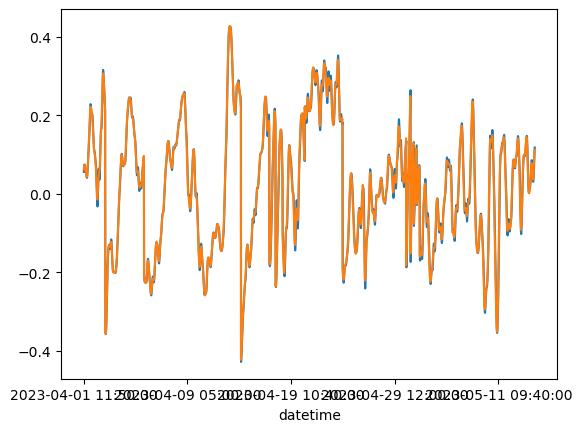

In [32]:
dfl_.set_index('datetime').velocity_east.plot()
dfv_.set_index('datetime').velocity_east.plot()

In [ ]:
dfl_